In [ ]:
import h5py
import matplotlib.pyplot as plt

# SET DATA PATH
DATA_EXACT_PATH = "../../data/simulations-exact.h5"
DATA_LINEAR_PATH = "../../data/simulations-linear.h5"
DATA_QUADRATIC_PATH = "../../data/simulations-quadratic.h5"

In [ ]:
# Check whether everything inside is ok
with h5py.File(DATA_EXACT_PATH, "r") as f:
    print(f.keys())
    print(f["layer_0"].keys())
    print(f["layer_0"]["f"])
    print(f["layer_0"]["q"])
    print(f["layer_0"]["v"])
    print(f["layer_0"]["bold"])

<KeysViewHDF5 ['layer_0', 'layer_1', 'layer_2', 'meta']>
<KeysViewHDF5 ['bold', 'f', 'q', 'q_star', 's', 'v', 'v_star', 'x']>
<HDF5 dataset "f": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "q": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "v": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "bold": shape (100, 100, 32, 32), type "<f2">


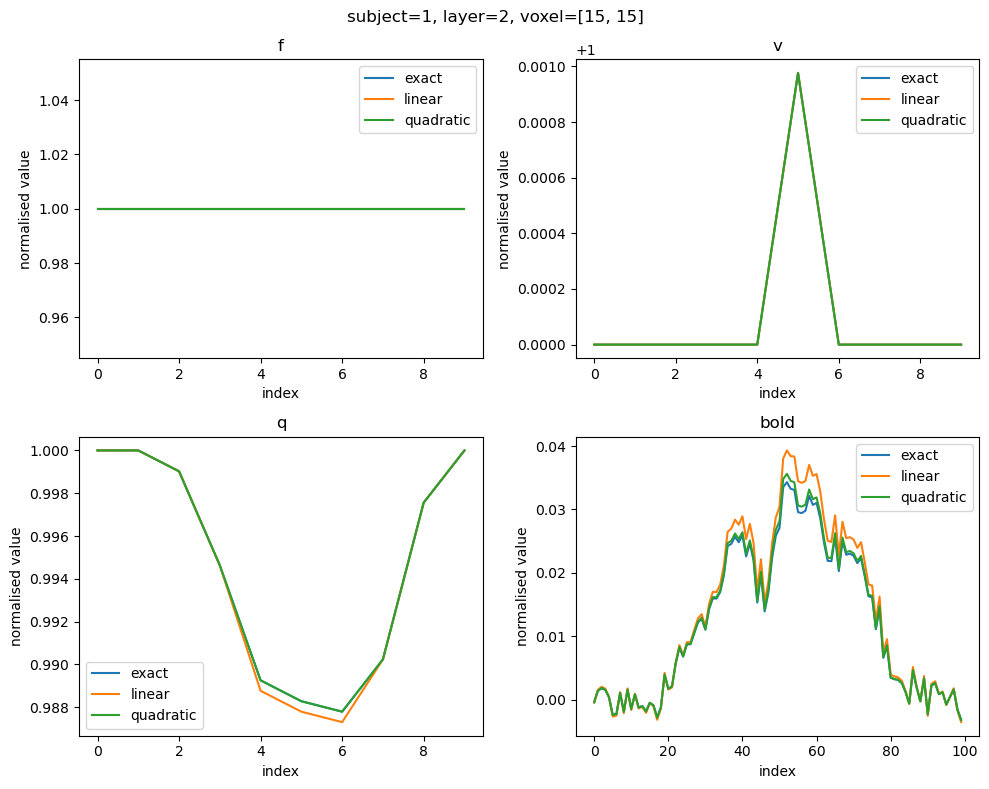

In [ ]:
# Plot observables

sub = 1
layer = 2
post = [15, 15]

variables = ["f", "v", "q", "bold"]

data = {}
for var in variables:
    lay = f"layer_{layer}"
    with h5py.File(DATA_EXACT_PATH, "r") as f:
        data[f"exact_{var}"] = f[lay][var][sub, :, *post]
    with h5py.File(DATA_LINEAR_PATH, "r") as f:
        data[f"linear_{var}"] = f[lay][var][sub, :, *post]
    with h5py.File(DATA_QUADRATIC_PATH, "r") as f:
        data[f"quadratic_{var}"] = f[lay][var][sub, :, *post]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    ax.plot(data[f"exact_{var}"], label="exact")
    ax.plot(data[f"linear_{var}"], label="linear")
    ax.plot(data[f"quadratic_{var}"], label="quadratic")
    ax.set_title(var)
    ax.set_xlabel("index")
    ax.set_ylabel("normalised value")
    ax.legend()

plt.suptitle(f"subject={sub}, layer={layer}, voxel={post}")
plt.tight_layout()
plt.savefig(f"figs/simulation-sub-{sub}-layer-{layer}-voxel-{post}.png", dpi=300)

<KeysViewHDF5 ['layer_0', 'layer_1', 'layer_2', 'meta']>
<KeysViewHDF5 ['bold', 'f', 'q', 'q_star', 's', 'v', 'v_star', 'x']>
<HDF5 dataset "f": shape (100, 100, 4, 4), type "<f2">
<HDF5 dataset "q": shape (100, 100, 4, 4), type "<f2">
<HDF5 dataset "v": shape (100, 100, 4, 4), type "<f2">
<HDF5 dataset "bold": shape (100, 100, 4, 4), type "<f2">


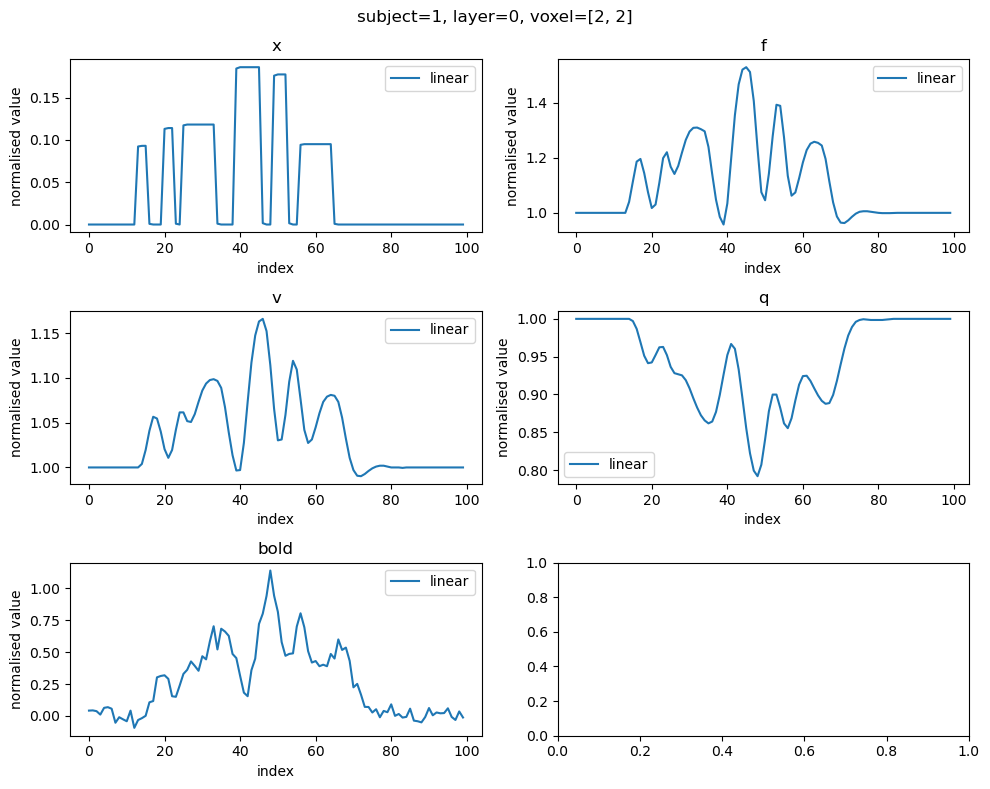

In [9]:
import h5py
import matplotlib.pyplot as plt

# SET DATA PATH
DATA_LINEAR_PATH = "../../data/simulations-linear-4x4.h5"

# Check whether everything inside is ok
with h5py.File(DATA_LINEAR_PATH, "r") as f:
    print(f.keys())
    print(f["layer_0"].keys())
    print(f["layer_0"]["f"])
    print(f["layer_0"]["q"])
    print(f["layer_0"]["v"])
    print(f["layer_0"]["bold"])

    # Plot observables

sub = 1
layer = 0
post = [2, 2]

variables = ["x", "f", "v", "q", "bold"]

data = {}
for var in variables:
    lay = f"layer_{layer}"
    with h5py.File(DATA_LINEAR_PATH, "r") as f:
        data[f"linear_{var}"] = f[lay][var][sub, :, *post]

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    ax.plot(data[f"linear_{var}"], label="linear")
    ax.set_title(var)
    ax.set_xlabel("index")
    ax.set_ylabel("normalised value")
    ax.legend()

plt.suptitle(f"subject={sub}, layer={layer}, voxel={post}")
plt.tight_layout()
# plt.savefig(f'figs/simulation-sub-{sub}-layer-{layer}-voxel-{post}.png', dpi=300)

In [10]:
import h5py
import matplotlib.animation as animation
import matplotlib.pyplot as plt

# SET DATA PATH
DATA_LINEAR_PATH = "../../data/simulations-linear-4x4.h5"

layers = [0, 1, 2]
variables = ["x", "bold"]
sub = 0  # subject index

# Load all data upfront
data = {}
with h5py.File(DATA_LINEAR_PATH, "r") as f:
    for layer in layers:
        lay = f"layer_{layer}"
        for var in variables:
            # Shape assumed: (subjects, time, x, y)
            data[(layer, var)] = f[lay][var][sub, :, :, :]  # (time, x, y)

n_time = data[(0, "x")].shape[0]

# Pre-compute color limits per (layer, var) for consistent colorbar across time
clims = {}
for layer in layers:
    for var in variables:
        d = data[(layer, var)]
        clims[(layer, var)] = (d.min(), d.max())

# Build figure
fig, axes = plt.subplots(len(variables), len(layers), figsize=(12, 8))
images = {}

for row, var in enumerate(variables):
    for col, layer in enumerate(layers):
        ax = axes[row, col]
        vmin, vmax = clims[(layer, var)]
        im = ax.imshow(
            data[(layer, var)][0, :, :],
            cmap="viridis",
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
        )
        plt.colorbar(im, ax=ax)
        ax.set_title(f"Layer {layer} — {var}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        images[(layer, var)] = im

title = fig.suptitle("Spatial maps at t=0", fontsize=14)
plt.tight_layout()


def update(t):
    for row, var in enumerate(variables):
        for col, layer in enumerate(layers):
            images[(layer, var)].set_data(data[(layer, var)][t, :, :])
    title.set_text(f"Spatial maps at t={t}")
    return list(images.values()) + [title]


ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_time,
    interval=100,  # ms between frames
    blit=True,
)

# Save as GIF
ani.save("spatial_maps.gif", writer="pillow", fps=10, dpi=150)
print("Saved to spatial_maps.gif")
plt.close()

Saved to spatial_maps.gif
